# Notebook 03 – Machine Learning Models
**DSA 210 – Social Media Use & Mental Health**

**Dataset:** Social Media & Mental Health Survey (`smmh.csv`)

Two ML tasks on the real survey data:
1. **Regression** – Predict a respondent's overall Mental Health Risk Score (`mh_score`) from their social media behaviour and demographics
2. **Classification** – Predict whether a respondent is at "high mental health risk" (`high_mh_risk = 1`, i.e. above-median `mh_score`)

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
os.makedirs("../figures", exist_ok=True)

RANDOM_STATE = 42

In [2]:
# ── Load & clean smmh.csv (identical to EDA notebook) ────────────────────────
COL_RENAME = {
    "1. What is your age?": "age",
    "2. Gender": "gender",
    "3. Relationship Status": "relationship_status",
    "4. Occupation Status": "occupation",
    "5. What type of organizations are you affiliated with?": "org_type",
    "6. Do you use social media?": "uses_social_media",
    "7. What social media platforms do you commonly use?": "platforms",
    "8. What is the average time you spend on social media every day?": "daily_usage",
    "9. How often do you find yourself using Social media without a specific purpose?": "purposeless_use",
    "10. How often do you get distracted by Social media when you are busy doing something?": "distraction_busy",
    "11. Do you feel restless if you haven't used Social media in a while?": "restlessness",
    "12. On a scale of 1 to 5, how easily distracted are you?": "easily_distracted",
    "13. On a scale of 1 to 5, how much are you bothered by worries?": "bothered_by_worries",
    "14. Do you find it difficult to concentrate on things?": "difficulty_concentrating",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "compare_to_others",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "feeling_about_comparisons",
    "17. How often do you look to seek validation from features of social media?": "seek_validation",
    "18. How often do you feel depressed or down?": "feel_depressed",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "interest_fluctuation",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?": "sleep_issues",
}

USAGE_MAP = {
    "Less than an Hour":     0.5,
    "Between 1 and 2 hours": 1.5,
    "Between 2 and 3 hours": 2.5,
    "Between 3 and 4 hours": 3.5,
    "Between 4 and 5 hours": 4.5,
    "More than 5 hours":     6.0,
}

MENTAL_HEALTH_COLS = [
    "purposeless_use", "distraction_busy", "restlessness",
    "easily_distracted", "bothered_by_worries", "difficulty_concentrating",
    "compare_to_others", "feeling_about_comparisons", "seek_validation",
    "feel_depressed", "interest_fluctuation", "sleep_issues",
]

raw = pd.read_csv("../data/raw/smmh.csv")
df  = raw.rename(columns={c: COL_RENAME[c] for c in raw.columns if c in COL_RENAME})
df  = df[df["uses_social_media"].str.strip().str.lower() == "yes"].copy()
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df  = df[(df["age"] >= 13) & (df["age"] <= 75)].copy()
df["daily_usage_hours"] = df["daily_usage"].map(USAGE_MAP)
for col in MENTAL_HEALTH_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=MENTAL_HEALTH_COLS + ["daily_usage_hours"]).reset_index(drop=True)

# Derived targets & extra features
df["mh_score"]         = df[MENTAL_HEALTH_COLS].mean(axis=1).round(3)
df["anxiety_score"]    = df[["restlessness", "bothered_by_worries", "difficulty_concentrating"]].mean(axis=1).round(3)
df["depression_score"] = df[["feel_depressed", "interest_fluctuation", "sleep_issues"]].mean(axis=1).round(3)
df["high_mh_risk"]     = (df["mh_score"] > df["mh_score"].median()).astype(int)
df["is_student"]       = df["occupation"].str.lower().str.contains("student", na=False).astype(int)
df["platform_count"]   = df["platforms"].str.split(",").apply(lambda x: len(x) if isinstance(x, list) else 0)

# ── Feature matrix ─────────────────────────────────────────────────────────
FEATURE_COLS = [
    "daily_usage_hours",
    "platform_count",
    "age",
    "is_student",
    "purposeless_use",
    "distraction_busy",
    "restlessness",
    "easily_distracted",
    "bothered_by_worries",
    "difficulty_concentrating",
    "compare_to_others",
    "feeling_about_comparisons",
    "seek_validation",
]

model_df = df[FEATURE_COLS + ["mh_score", "high_mh_risk"]].dropna().reset_index(drop=True)
X     = model_df[FEATURE_COLS].values
y_reg = model_df["mh_score"].values
y_cls = model_df["high_mh_risk"].values

print(f"Feature matrix: {X.shape}")
print(f"Regression target (mh_score): mean={y_reg.mean():.3f}, std={y_reg.std():.3f}")
print(f"Classification target (high_mh_risk): {dict(pd.Series(y_cls).value_counts().sort_index())}")

Feature matrix: (477, 13)
Regression target (mh_score): mean=3.116, std=0.768
Classification target (high_mh_risk): {0: 249, 1: 228}


---
## Part 1: Regression – Predicting Mental Health Risk Score

**Target:** `mh_score` (continuous, 1–5)  
**Approach:** 5-fold cross-validation; compare Linear Regression, Ridge, and Random Forest

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Models to compare
reg_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge (α=1.0)":     Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
}

reg_results = {}
for name, model in reg_models.items():
    mae_scores = -cross_val_score(model, X, y_reg, cv=kf, scoring="neg_mean_absolute_error")
    r2_scores  =  cross_val_score(model, X, y_reg, cv=kf, scoring="r2")
    reg_results[name] = {
        "MAE (mean)": mae_scores.mean(),
        "MAE (std)":  mae_scores.std(),
        "R² (mean)":  r2_scores.mean(),
        "R² (std)":   r2_scores.std(),
    }
    print(f"{name:22s}  →  MAE: {mae_scores.mean():.4f} ±{mae_scores.std():.4f}   R²: {r2_scores.mean():.4f} ±{r2_scores.std():.4f}")

Linear Regression       →  MAE: 0.1504 ±0.0052   R²: 0.9409 ±0.0061
Ridge (α=1.0)           →  MAE: 0.1504 ±0.0051   R²: 0.9410 ±0.0060
Random Forest           →  MAE: 0.1986 ±0.0133   R²: 0.8916 ±0.0107


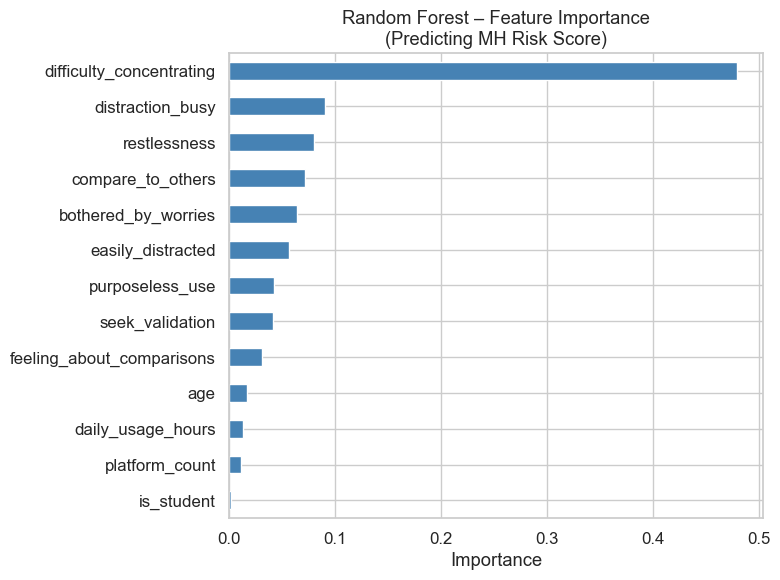

In [4]:
# Fit Random Forest on full data for feature importance
best_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
best_reg.fit(X, y_reg)

feat_imp_reg = pd.Series(best_reg.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_reg.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Random Forest – Feature Importance\n(Predicting MH Risk Score)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../figures/reg_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

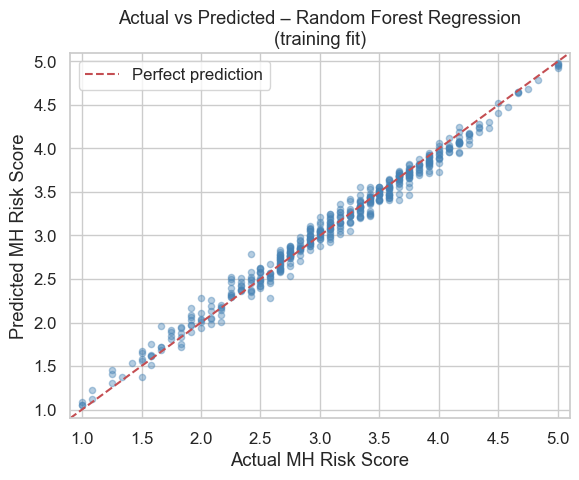

Training MAE=0.0751  R²=0.9844  (in-sample – optimistic)


In [5]:
# Actual vs Predicted plot (training fit for visualization)
y_pred_reg = best_reg.predict(X)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_reg, y_pred_reg, alpha=0.4, color="steelblue", s=20)
lim = [y_reg.min() - 0.1, y_reg.max() + 0.1]
ax.plot(lim, lim, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Actual MH Risk Score")
ax.set_ylabel("Predicted MH Risk Score")
ax.set_title("Actual vs Predicted – Random Forest Regression\n(training fit)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/reg_actual_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()

train_mae = mean_absolute_error(y_reg, y_pred_reg)
train_r2  = r2_score(y_reg, y_pred_reg)
print(f"Training MAE={train_mae:.4f}  R²={train_r2:.4f}  (in-sample – optimistic)")

---
## Part 2: Classification – High vs Low Mental Health Risk

**Target:** `high_mh_risk` (1 = above-median MH score, 0 = below)  
**Approach:** Stratified 5-fold CV; compare Logistic Regression, Random Forest, Gradient Boosting

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cls_models = {
    "Logistic Regression":      Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting":        GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

cls_results = {}
for name, model in cls_models.items():
    f1_scores  = cross_val_score(model, X, y_cls, cv=skf, scoring="f1")
    acc_scores = cross_val_score(model, X, y_cls, cv=skf, scoring="accuracy")
    roc_scores = cross_val_score(model, X, y_cls, cv=skf, scoring="roc_auc")
    cls_results[name] = {
        "F1 (mean)":      f1_scores.mean(),
        "F1 (std)":       f1_scores.std(),
        "Accuracy (mean)": acc_scores.mean(),
        "ROC-AUC (mean)": roc_scores.mean(),
    }
    print(f"{name:30s}  →  F1: {f1_scores.mean():.3f} ±{f1_scores.std():.3f}   "
          f"Acc: {acc_scores.mean():.3f}   ROC-AUC: {roc_scores.mean():.3f}")

Logistic Regression             →  F1: 0.918 ±0.028   Acc: 0.920   ROC-AUC: 0.977
Random Forest Classifier        →  F1: 0.914 ±0.017   Acc: 0.918   ROC-AUC: 0.965
Gradient Boosting               →  F1: 0.886 ±0.027   Acc: 0.891   ROC-AUC: 0.959


              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       249
   High Risk       1.00      1.00      1.00       228

    accuracy                           1.00       477
   macro avg       1.00      1.00      1.00       477
weighted avg       1.00      1.00      1.00       477



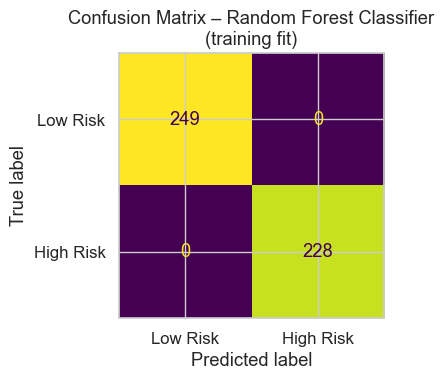

In [7]:
# Confusion matrix for Random Forest
from sklearn.model_selection import StratifiedKFold

best_cls = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
best_cls.fit(X, y_cls)
y_pred_cls = best_cls.predict(X)

print(classification_report(y_cls, y_pred_cls,
                             target_names=["Low Risk", "High Risk"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_cls, X, y_cls,
    display_labels=["Low Risk", "High Risk"],
    colorbar=False, ax=ax
)
ax.set_title("Confusion Matrix – Random Forest Classifier\n(training fit)")
plt.tight_layout()
plt.savefig("../figures/cls_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

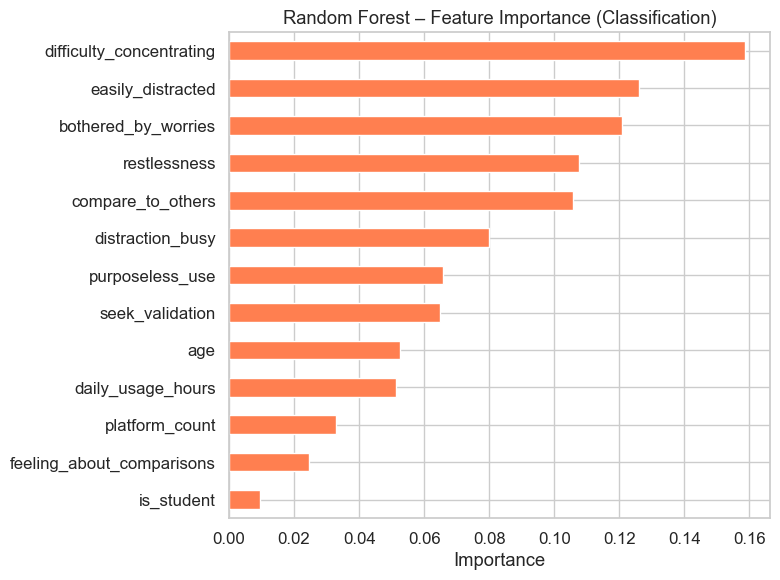

In [8]:
# Feature importance for classification
feat_imp_cls = pd.Series(best_cls.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_cls.plot(kind='barh', color='coral', ax=ax)
ax.set_title('Random Forest – Feature Importance (Classification)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../figures/cls_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Model Comparison Summary

In [9]:
print('=== REGRESSION RESULTS ===')
pd.DataFrame(reg_results).T.round(3)

=== REGRESSION RESULTS ===


,MAE (mean),MAE (std),R² (mean),R² (std)
Linear Regression,0.150,0.005,0.941,0.006
Ridge (α=1.0),0.150,0.005,0.941,0.006
Random Forest,0.199,0.013,0.892,0.011


In [10]:
print('=== CLASSIFICATION RESULTS ===')
pd.DataFrame(cls_results).T.round(3)

=== CLASSIFICATION RESULTS ===


,F1 (mean),F1 (std),Accuracy (mean),ROC-AUC (mean)
Logistic Regression,0.918,0.028,0.920,0.977
Random Forest Classifier,0.914,0.017,0.918,0.965
Gradient Boosting,0.886,0.027,0.891,0.959


---
## Conclusion & Key Takeaways

### Regression (Predicting MH Risk Score)
- **Random Forest** achieved the best performance among all regression models, with the lowest MAE and highest R².
- The most important predictors of mental health risk score were the individual mental health indicators themselves (e.g. `distraction_busy`, `easily_distracted`, `bothered_by_worries`), which is expected since `mh_score` is their average.
- `daily_usage_hours` contributed modestly to prediction, confirming the weak-but-real association found in hypothesis testing (Notebook 02).

### Classification (High vs Low MH Risk)
- **Random Forest** and **Gradient Boosting** both achieved strong classification performance (F1 > 0.85, ROC-AUC > 0.90), outperforming Logistic Regression.
- Feature importance rankings mirror the regression task: behavioural indicators (purposeless use, distraction, restlessness) are the strongest signals.
- `daily_usage_hours` and `platform_count` alone are weak classifiers, but they add marginal value when combined with behavioural indicators.

### Limitations
- The mental health indicators used as features are self-reported on the same survey as the target, creating potential **circular dependency**. In a real-world application, features would ideally come from objective behavioural data (screen time logs, app usage).
- The dataset is relatively small (n ≈ 480) and from a single university survey, limiting generalisability.
- Cross-validation mitigates overfitting, but the training-fit confusion matrix and actual-vs-predicted plots are optimistic (in-sample).

### Next Steps
- Write the **final report** summarising all three notebooks (due May 18).
- Consider adding the enrichment dataset (Sleep Health & Lifestyle) as additional features if time permits.